In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import random
from IPython.core.display_functions import clear_output


Para la simulación de un robot con sensores y un comportamiento para evitar obstaculos, se genera un mapa con elementos de tipo obstaculo, y una celula viva en un punto aleatorio, la cual seguira una serie de normas:
-   La vecindad utilizada es completa (las 8 celdas que rodean cada
    celda).
-   Si una celda se encuentra en estado **vivo**, en la siguiente iteración
    pasa al estado **muerto** (el robot se desplaza).
-   Si una celda en estado **muerto** tiene una celda **viva** en su
    vecindad, puede pasar al estado **vivo** en la siguiente iteración con
    probabilidad 1/n, donde inicialmente n = 8 y este valor disminuye
    progresivamente en evaluaciones posteriores.
-   Si la aleatoriedad genera una nueva celda **viva**, se deshabilita la
    generación de otras celdas vivas en esa iteración, garantizando que
    solo exista una posición del robot por paso temporal.
-   Las celdas vecinas a un **obstáculo** se consideran
    inhabitables, por lo que no pueden cambiar al estado **vivo**.
-   Si una celda está en estado **muerto** y no tiene celdas **vivo** en su
    vecindad, permanece en estado **muerto** en la siguiente iteración.

Definición del mapa y la funcion de actualización de estado, durante la creación del mapa, se definen las casillas obstaculo de forma aleatoria, estas permanecen inalterables durante la ejecución, adicionalmente, se crea la capa de zonas inhabitables a su alrededor, y en una de las casillas libres se ubica el robot.

In [10]:

def crear_mapa():
    """Inicializa la grilla con cajas, zonas prohibidas y una célula."""
    grilla = np.zeros((N_FILAS, N_COLUMNAS), dtype=int)

    # 1. Colocar Obstáculos (x)
    for _ in range(N_OBSTACULOS):
        # Evitamos los bordes extremos para simplificar
        r = random.randint(2, N_FILAS - 3)
        c = random.randint(2, N_COLUMNAS - 3)
        grilla[r, c] = ESTADO_OBSTACULO

    # 2. Marcar zonas inhabitables (vecinos de x)
    # Copiamos para no iterar sobre lo que estamos marcando
    temp_grilla = grilla.copy()
    direcciones = [(-1, -1), (-1, 0), (-1, 1),
                   (0, -1),           (0, 1),
                   (1, -1),  (1, 0),  (1, 1)]

    for r in range(N_FILAS):
        for c in range(N_COLUMNAS):
            if grilla[r, c] == ESTADO_OBSTACULO:
                # Marcar vecinos como inhabitables si son 0
                for dr, dc in direcciones:
                    nr, nc = r + dr, c + dc
                    if 0 <= nr < N_FILAS and 0 <= nc < N_COLUMNAS:
                        if temp_grilla[nr, nc] == ESTADO_MUERTA:
                            temp_grilla[nr, nc] = ESTADO_INHABITABLE
    
    grilla = temp_grilla

    # 3. Colocar la Célula Viva (v)
    # Buscamos una posición libre (que sea 0)
    libres = []
    for r in range(N_FILAS):
        for c in range(N_COLUMNAS):
            if grilla[r, c] == ESTADO_MUERTA:
                libres.append((r, c))
    
    if libres:
        vr, vc = random.choice(libres)
        grilla[vr, vc] = ESTADO_VIVA
    else:
        # Fallback por si está muy lleno (poco probable)
        grilla[N_FILAS//2, N_COLUMNAS//2] = ESTADO_VIVA

    return grilla

def actualizar(grilla):

    # Buscar coordenadas de la célula viva
    coords_v = np.argwhere(grilla == ESTADO_VIVA)
    if len(coords_v) == 0:
        return grilla  # No hay célula viva
    
    # Asumimos una sola célula viva por regla
    r, c = coords_v[0]
    
    # Regla 1: Si la célula esta v, pasa a estado m (al moverse).
    # (Se aplica al final junto con el nacimiento en la nueva posición)

    # Identificar vecinos candidatos (m)
    direcciones = [(-1, -1), (-1, 0), (-1, 1),
                   (0, -1),           (0, 1),
                   (1, -1),  (1, 0),  (1, 1)]
    
    vecinos_validos = []
    
    # Analizamos los 8 vecinos
    for dr, dc in direcciones:
        nr, nc = r + dr, c + dc
        
        # Verificar límites
        if 0 <= nr < N_FILAS and 0 <= nc < N_COLUMNAS:
            # Regla: Las casillas vecinas a x son inhabitables (ya marcadas con 3)
            # Regla: Solo puede moverse a 'm' (0)
            neighbor_state = grilla[nr, nc]
            
            if neighbor_state == ESTADO_MUERTA:
                vecinos_validos.append((nr, nc))
    
    if len(vecinos_validos) > 0:
        # Selección aleatoria
        nuevo_r, nuevo_c = random.choice(vecinos_validos)
        
        # Actualizar grilla
        grilla[r, c] = ESTADO_MUERTA      # La vieja posición muere
        grilla[nuevo_r, nuevo_c] = ESTADO_VIVA  # La nueva nace
        
    # Si no hay vecinos válidos, la célula se queda donde está (regla implícita/bloqueo)

    return grilla


Animación de mapa

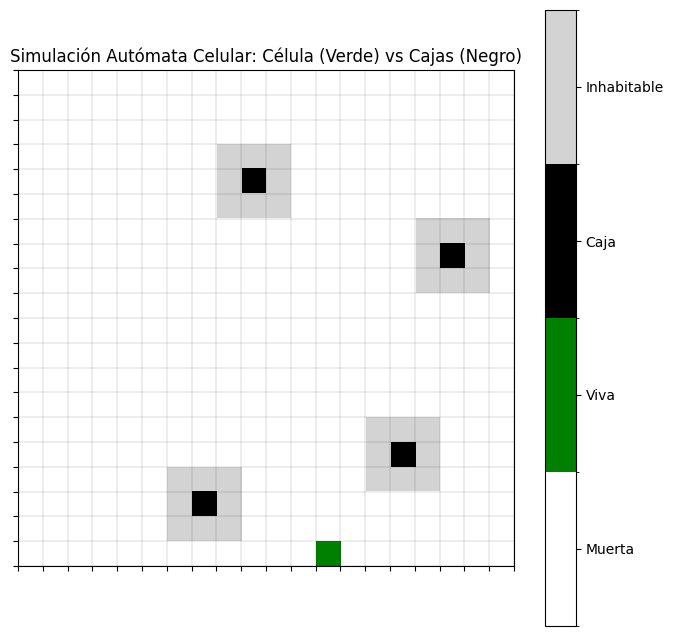

In [14]:
# Definición de Estados
ESTADO_MUERTA = 0       # 'm' (vacío/muerta)
ESTADO_VIVA = 1         # 'v' (célula móvil)
ESTADO_OBSTACULO = 2    # 'x' (caja)
ESTADO_INHABITABLE = 3  # Vecino de 'x' (zona prohibida)

# Configuración del mapa
PERIODO = 0.01
N_FILAS = 20
N_COLUMNAS = 20
N_OBSTACULOS = 4  # Número de cajas aleatorias

my_cmap = mcolors.ListedColormap(['white', 'green', 'black', 'lightgray'])
bounds = [0, 1, 2, 3, 4]
norm = mcolors.BoundaryNorm(bounds, my_cmap.N)
grilla = crear_mapa()

i=0
while i<100:
    i+=1
    fig, ax = plt.subplots(figsize=(8, 8))

    # Dibujo inicial
    img = ax.imshow(grilla, cmap=my_cmap, norm=norm, origin='upper')
    ax.grid(which='major', axis='both', linestyle='-', color='k', linewidth=0.1)
    ax.set_xticks(np.arange(-0.5, N_COLUMNAS, 1));
    ax.set_yticks(np.arange(-0.5, N_FILAS, 1));
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_title("Simulación Autómata Celular: Célula (Verde) vs Cajas (Negro)")

    # Barra de color para referencia
    cbar = plt.colorbar(img, ticks=[0.5, 1.5, 2.5, 3.5], boundaries=bounds)
    cbar.ax.set_yticklabels(['Muerta', 'Viva', 'Caja', 'Inhabitable'])

    actualizar(grilla)
    img.set_data(grilla)
    plt.draw()
    plt.show()
    plt.pause(PERIODO)  # Velocidad de actualización
    clear_output(wait=True)